# Experiment Comparison Notebook

Load one experiment directory and compare the selected scenario against the four baselines generated by `run_workflow_experiment.py`. The notebook expects the experiment folder to contain the Step 5 outputs:

- `evaluation_selected_*`
- `evaluation_one_agent_all_tasks_*`
- `evaluation_one_agent_per_task_*`
- `evaluation_one_agent_per_workflow_*`
- `evaluation_one_agent_per_node_*`

The plotted `step` values are simulator evaluation intervals from `eval_interval`, not agent decision steps. To get more of them, run the experiment longer with a higher `--iterations` value, for example `--iterations 1000`.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 140)
pd.set_option('display.float_format', lambda value: f'{value:,.3f}')

SCENARIO_LABELS = {
    'selected': 'Selected configuration',
    'one_agent_all_tasks': '1 agent for all tasks',
    'one_agent_per_task': '1 agent per task',
    'one_agent_per_workflow': '1 agent per workflow',
    'one_agent_per_node': '1 agent per node',
}

# Change this to the experiment directory you want to inspect.
EXPERIMENT_DIR = Path('experiments/exp_wf02')
if not EXPERIMENT_DIR.exists():
    raise FileNotFoundError(f'Experiment directory not found: {EXPERIMENT_DIR}')

EXPERIMENT_DIR

PosixPath('experiments/exp_wf02')

In [2]:
def load_scenarios(exp_dir: Path) -> list[dict[str, object]]:
    manifest_path = exp_dir / 'evaluation_manifest.json'
    if manifest_path.exists():
        manifest = json.loads(manifest_path.read_text())
        scenarios = manifest.get('scenarios', [])
        if scenarios:
            return scenarios

    return [
        {'scenario': 'selected'},
        {'scenario': 'one_agent_all_tasks'},
        {'scenario': 'one_agent_per_task'},
        {'scenario': 'one_agent_per_workflow'},
        {'scenario': 'one_agent_per_node'},
    ]


def scenario_files(exp_dir: Path, scenario: str) -> tuple[Path, Path]:
    detail_csv = exp_dir / f'evaluation_{scenario}_step_kpis.csv'
    summary_json = exp_dir / f'evaluation_{scenario}_summary.json'
    if not detail_csv.exists():
        raise FileNotFoundError(f'Missing detailed KPI file: {detail_csv}')
    if not summary_json.exists():
        raise FileNotFoundError(f'Missing scenario summary file: {summary_json}')
    return detail_csv, summary_json


def mean_node_cpu(detail_df: pd.DataFrame) -> pd.Series:
    cpu_cols = [col for col in detail_df.columns if col.endswith('_avg_cpu_usage_pct')]
    if not cpu_cols:
        return pd.Series([np.nan] * len(detail_df))
    return detail_df[cpu_cols].mean(axis=1)


def mean_violation_pct(detail_df: pd.DataFrame) -> pd.Series:
    trace_cols = [col for col in detail_df.columns if col.endswith('_total_traces')]
    if not trace_cols:
        return pd.Series([np.nan] * len(detail_df))
    total_traces = detail_df[trace_cols].sum(axis=1).replace(0, np.nan)
    return 100.0 * detail_df['total_violations'] / total_traces


scenarios = load_scenarios(EXPERIMENT_DIR)
summary_rows: list[dict[str, object]] = []
detail_frames: dict[str, pd.DataFrame] = {}
summary_payloads: dict[str, dict[str, object]] = {}

for item in scenarios:
    scenario = str(item.get('scenario', '')).strip()
    if not scenario:
        continue

    detail_csv, summary_json = scenario_files(EXPERIMENT_DIR, scenario)
    detail_df = pd.read_csv(detail_csv)
    summary_payload = json.loads(summary_json.read_text())

    detail_frames[scenario] = detail_df
    summary_payloads[scenario] = summary_payload

    violation_pct = mean_violation_pct(detail_df)

    row = {
        'scenario': scenario,
        'label': SCENARIO_LABELS.get(scenario, scenario),
        'n_steps': int(summary_payload.get('n_steps', len(detail_df))),
        'total_violations': int(summary_payload.get('total_violations_across_steps', detail_df['total_violations'].sum())),
        'mean_step_violation_pct': float(violation_pct.mean()),
        'max_step_violation_pct': float(violation_pct.max()),
        'mean_step_total_violations': float(summary_payload.get('mean_step_total_violations', detail_df['total_violations'].mean())),
        'max_step_total_violations': int(detail_df['total_violations'].max()),
        'mean_step_cpu_usage_pct': float(mean_node_cpu(detail_df).mean()),
    }

    node_mean_cols = [col for col in summary_payload.keys() if col.endswith('_avg_cpu_usage_pct_mean')]
    for col in sorted(node_mean_cols):
        row[col] = float(summary_payload[col])

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values('scenario').reset_index(drop=True)
summary_df

,scenario,label,n_steps,total_violations,mean_step_violation_pct,max_step_violation_pct,mean_step_total_violations,max_step_total_violations,mean_step_cpu_usage_pct,node0_avg_cpu_usage_pct_mean,node1_avg_cpu_usage_pct_mean,node2_avg_cpu_usage_pct_mean
0,one_agent_all_tasks,1 agent for all tasks,9,7,8.504,16.667,0.778,2,55.513,80.505,57.828,28.207
1,one_agent_per_node,1 agent per node,9,58,78.862,100.000,6.444,11,55.185,84.571,54.141,26.843
2,one_agent_per_task,1 agent per task,9,51,72.293,100.000,5.667,10,54.613,84.823,53.030,25.985
3,one_agent_per_workflow,1 agent per workflow,9,48,62.716,100.000,5.333,11,55.783,87.677,53.384,26.288
4,selected,Selected configuration,9,34,42.753,85.714,3.778,8,59.571,90.051,59.141,29.520


## Summary comparison

The table below compares the selected mapping against the baselines using the per-step KPI files written by Step 5. The main KPI shown here is the violation percentage per evaluation interval.

In [3]:
display(summary_df[[
    'label',
    'n_steps',
    'total_violations',
    'mean_step_violation_pct',
    'max_step_violation_pct',
    'mean_step_cpu_usage_pct',
]])

selected_mean_pct = float(summary_df.loc[summary_df['scenario'] == 'selected', 'mean_step_violation_pct'].iloc[0]) if 'selected' in set(summary_df['scenario']) else None
if selected_mean_pct is not None:
    comparison = summary_df[['label', 'mean_step_violation_pct']].copy()
    comparison['delta_vs_selected'] = comparison['mean_step_violation_pct'] - selected_mean_pct
    display(comparison.sort_values('delta_vs_selected'))

,label,n_steps,total_violations,mean_step_violation_pct,max_step_violation_pct,mean_step_cpu_usage_pct
0,1 agent for all tasks,9,7,8.504,16.667,55.513
1,1 agent per node,9,58,78.862,100.000,55.185
2,1 agent per task,9,51,72.293,100.000,54.613
3,1 agent per workflow,9,48,62.716,100.000,55.783
4,Selected configuration,9,34,42.753,85.714,59.571


,label,mean_step_violation_pct,delta_vs_selected
0,1 agent for all tasks,8.504,-34.248
4,Selected configuration,42.753,0.000
3,1 agent per workflow,62.716,19.964
2,1 agent per task,72.293,29.540
1,1 agent per node,78.862,36.110


## Per-step comparisons

The first plot shows violation percentage per evaluation interval. The second plot shows average node CPU usage per evaluation interval.

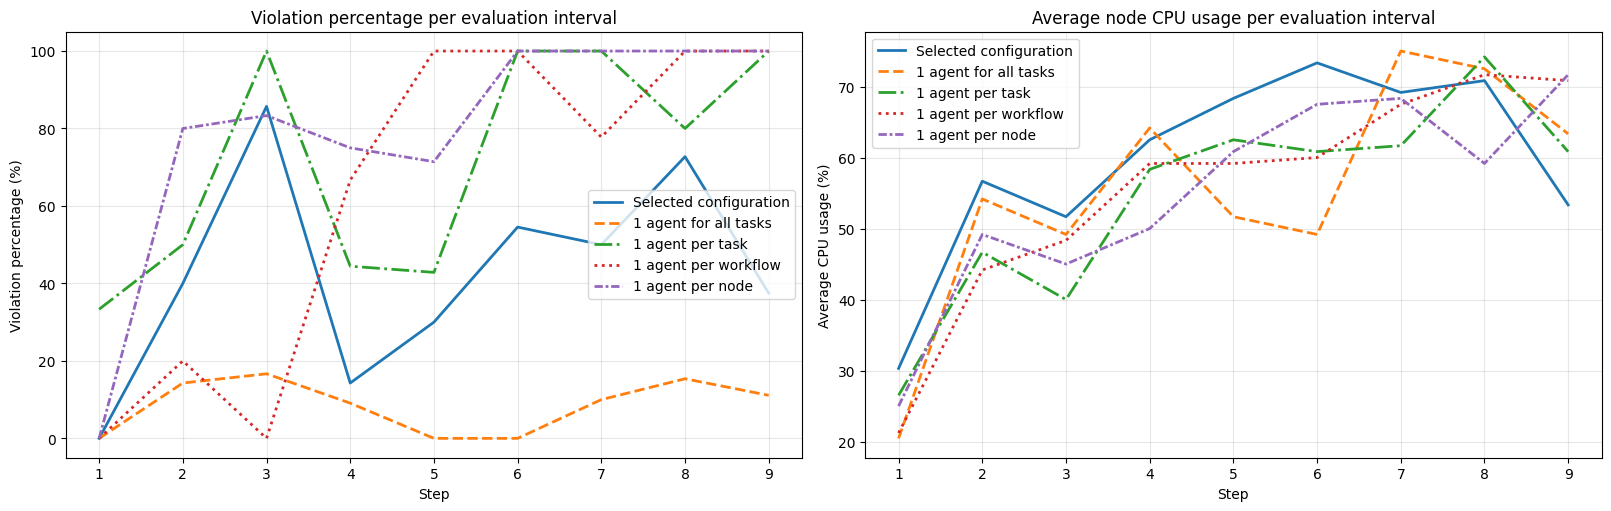

In [4]:
plot_order = ['selected', 'one_agent_all_tasks', 'one_agent_per_task', 'one_agent_per_workflow', 'one_agent_per_node']
plot_items = [(scenario, detail_frames[scenario]) for scenario in plot_order if scenario in detail_frames]
colors = plt.cm.tab10.colors
linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))]

fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

for idx, (scenario, detail_df) in enumerate(plot_items):
    label = SCENARIO_LABELS.get(scenario, scenario)
    x = detail_df['step'] if 'step' in detail_df.columns else np.arange(1, len(detail_df) + 1)
    axes[0].plot(x, mean_violation_pct(detail_df), label=label, color=colors[idx % len(colors)], linestyle=linestyles[idx % len(linestyles)], linewidth=2)
    axes[1].plot(x, mean_node_cpu(detail_df), label=label, color=colors[idx % len(colors)], linestyle=linestyles[idx % len(linestyles)], linewidth=2)

axes[0].set_title('Violation percentage per evaluation interval')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Violation percentage (%)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_title('Average node CPU usage per evaluation interval')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Average CPU usage (%)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.show()

## Detailed per-step data

Inspect one scenario at a time by changing `SCENARIO_TO_SHOW`.

In [5]:
SCENARIO_TO_SHOW = 'selected'

if SCENARIO_TO_SHOW not in detail_frames:
    raise KeyError(f'Unknown scenario: {SCENARIO_TO_SHOW}')

display(detail_frames[SCENARIO_TO_SHOW].head(20))

,step,elapsed,sim_time,wf0_total_traces,wf0_violation_rate,wf0_violations,wf1_total_traces,wf1_violation_rate,wf1_violations,total_violations,node0_avg_cpu_threads,node0_avg_cpu_usage_pct,node1_avg_cpu_threads,node1_avg_cpu_usage_pct,node2_avg_cpu_threads,node2_avg_cpu_usage_pct
0,1,10.000,10.000,2,0.000,0,2,0.000,0,0,1.818,45.455,1.091,27.273,0.727,18.182
1,2,10.000,20.000,2,0.500,1,3,0.333,1,2,4.000,100.000,1.800,45.000,1.000,25.000
2,3,10.000,30.000,2,1.000,2,5,0.800,4,6,3.500,87.500,1.900,47.500,0.800,20.000
3,4,10.000,40.000,2,0.000,0,5,0.200,1,1,3.700,92.500,2.700,67.500,1.100,27.500
4,5,10.000,50.000,5,0.000,0,5,0.600,3,3,4.000,100.000,2.900,72.500,1.300,32.500
5,6,10.000,60.000,5,0.200,1,6,0.833,5,6,4.000,100.000,3.000,75.000,1.800,45.000
6,7,10.000,70.000,3,0.333,1,7,0.571,4,5,4.000,100.000,2.800,70.000,1.500,37.500
7,8,10.000,80.000,5,1.000,5,6,0.500,3,8,4.000,100.000,3.000,75.000,1.500,37.500
8,9,10.000,90.000,3,1.000,3,5,0.000,0,3,3.400,85.000,2.100,52.500,0.900,22.500
